---
title: "Nielsen's NNDL, ch.3B"
execute:
  # echo: false
  freeze: auto  # re-render only when source changes
format:
  html:
    code-fold: true
    code-summary: "Show the code"
---

In [7]:
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [8]:
import ch3_code

In [3]:
#| code-summary: "load MNIST data into memory"
training_data, test_data = ch3_code.load_mnist_from_web()
print(f"Loaded {len(training_data)} training samples directly into memory.")

Fetching train_img...
Fetching train_lbl...
Fetching test_img...
Fetching test_lbl...
Loaded 60000 training samples directly into memory.


In [5]:
net = ch3_code.NN2(layer_sizes=[784, 30, 10], activation="sigmoid", rand_seed=3)
res = net.stochastic_gradient_descent(
    training_data=training_data[:1000],
    test_data=test_data,
    epochs=100,
    batch_size=10,
    eta=0.5,
    monitoring=True
    )

            ETA:? 

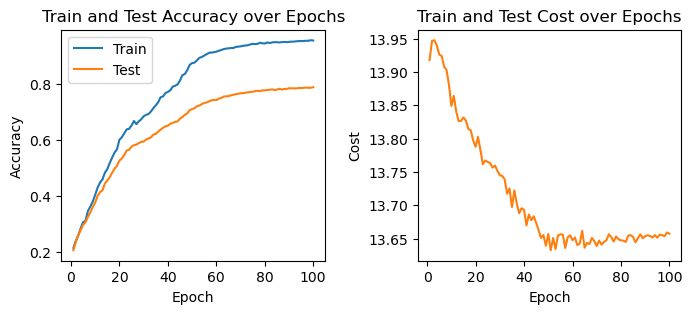

In [18]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(1, 2, figsize=(8, 3))
fig.subplots_adjust(wspace=0.35)
ax[0].plot(res["epoch"], res["train_accuracy"], label="Train")
ax[0].plot(res["epoch"], res["test_accuracy"], label="Test")
ax[0].set_xlabel("Epoch")
ax[0].set_ylabel("Accuracy")
ax[0].set_title("Train and Test Accuracy over Epochs")
ax[0].legend() 

# ax[1].plot(res["epoch"], res["train_cost"], label="Train Cost")
ax[1].plot(res["epoch"], res["test_cost"], label="Test Cost", color="tab:orange")
ax[1].set_xlabel("Epoch")
ax[1].set_ylabel("Cost")
ax[1].set_title("Train and Test Cost over Epochs");

In [ ]:
import sys
sys.stdout.flush()
import os
import io
import gzip
import numpy as np
import requests
import matplotlib.pyplot as plt
from tqdm.notebook import tqdm
import matplotlib.patches as patches
import json
import time


class CrossEntropyCost:
    @staticmethod
    def fn(a, y):
        return np.sum(
            np.nan_to_num(    # ensures numerical stability
                - y * np.log(a) - (1-y) * np.log(1-a)
            )
        )
    
    @staticmethod
    def delta(z, a, y, activation):   # z is kept for compatibility / consistency
        if activation == SigmoidActivation:
            return (a - y)
        return (a - y) / (a * (1 - a)) * activation.prime(z)

class QuadraticCost:
    @staticmethod
    def fn(a, y):
        return np.linalg.norm(a-y)**2 / 2
    
    @staticmethod
    def delta(z, a, y, activation):
        return (a - y) * activation.prime(z)

class SigmoidActivation:
    @staticmethod
    def fn(z):
        return 1.0 / (1.0 + np.exp(-z))

    @staticmethod
    def prime(z):
        s = SigmoidActivation.fn(z)
        return s * (1 - s)

class ReLUActivation:
    @staticmethod
    def fn(z):
        return np.maximum(0, z)
    
    @staticmethod
    def prime(z):
        return np.where(z > 0, 1.0, 0.0)

class NN2:
    def __init__(self, layer_sizes, rand_seed=0, activation=SigmoidActivation, cost=CrossEntropyCost):
        """Initialize the neural network with the given layer sizes.
        For example, if layer_sizes = [50, 15, 20, 10], then we have a
        network with 50 input neurons, 15 neurons in hidden layer 0,
        20 neurons in hidden layer 1, and 10 output neurons (layer 3).
        """
        self.number_of_layers = len(layer_sizes) - 1
        self.layer_sizes = layer_sizes
        self.rng = np.random.default_rng(seed=rand_seed)
        self.activation = activation
        self.cost = cost
        self.default_weight_initializer()

    def default_weight_initializer(self):
        # input layer has no weights nor biases, so we skip it.

        # each neuron get 1 bias, so bias vector has the size of the layer
        # we skip the first (input) layer, it doesn't have biases
        # I made the biases to be matrices of shape (N_b, 1) instead of vectors of shape (N_b,)
        # to make the broadcasting work more smoothly in the feedforward and backpropagation functions.
        self.biases = [self.rng.normal(loc=0, scale=1, size=(N_b, 1))
                       for N_b in self.layer_sizes[1:]]
        # each neuron in layer Right is connected to all neurons in layer Left,
        # so weight matrix has the shape (size_right, size_left)
        # again, we skip the first (input) layer, it doesn't have weights
        # scale_for_weights = 1 / np.sqrt(size_left)
        self.weights = [self.rng.normal(loc=0, scale=1/np.sqrt(size_left), size=(size_right, size_left))
                        for size_left, size_right in
                          zip(self.layer_sizes[:-1],self.layer_sizes[1:])
                        ]
    
    def large_weight_initializer(self):
        """same logic as above"""
        self.biases = [self.rng.normal(loc=0, scale=1, size=(N_b, 1))
                       for N_b in self.layer_sizes[1:]]
        self.weights = [self.rng.normal(loc=0, scale=1, size=(size_right, size_left))
                        for size_left, size_right in
                          zip(self.layer_sizes[:-1],self.layer_sizes[1:])
                        ]

    
    def feedforward(self, a):
        """given input `a` from the first layer,
           we sequencially compute the activations of each layer
           `feedforward` returns the activations of last (output) layer
        """
        for b, w in zip(self.biases, self.weights):
            z = np.dot(w, a) + b
            a = self.activation.fn(z)
        return a
    
    def stochastic_gradient_descent(self,
                                    training_data,
                                    test_data,
                                    epochs,
                                    batch_size,
                                    eta,
                                    lmbda = 0.0,
                                    monitoring=False):
        n = len(training_data)
        lambda_over_n = lmbda / n
        try:
            if monitoring:
                monitoring_dict = {
                    "epoch": [],
                    "runtime_seconds": [],
                    "test_cost": [],
                    "test_accuracy": [],
                    "train_cost": [],
                    "train_accuracy": []
                }
                x_train = np.hstack([x for x, y in training_data])
                y_train = np.hstack([y for x, y in training_data])
                x_test = np.hstack([x for x, y in test_data])
                y_test = np.hstack([y for x, y in test_data])
            pbar = tqdm(
                range(1, epochs + 1),
                total=epochs,
                bar_format="{desc} {bar} ETA:{remaining} {postfix}", 
                leave=True,
                mininterval=0.0,   # update every epoch
                maxinterval=0.0
            )
            pbar.container.children[1].layout.width = "150px"
            for epoch_j in pbar:
                # shuffle training data at the beginning of each epoch
                self.rng.shuffle(training_data)
                # split training data into batches
                batches = [
                    training_data[k:k+batch_size]
                    for k in range(0, n, batch_size)
                ]

                start_time = time.perf_counter()
                # now loop over batches, update weights
                for batch in batches:
                    self.update_params_batch(batch, eta, lambda_over_n)
                duration_seconds = time.perf_counter() - start_time
                accuracy = self.evaluate(test_data) / len(test_data)
                pbar.set_description(f"Epoch: {epoch_j}/{epochs}")
                pbar.set_postfix_str(
                    f"test acc = {accuracy:.2%}, time/epoch = {duration_seconds:.2f}s"
                )
                if monitoring:
                    monitoring_dict["epoch"].append(epoch_j)
                    monitoring_dict["runtime_seconds"].append(duration_seconds)
                    monitoring_dict["train_accuracy"].append(self.evaluate(training_data)/len(training_data))
                    monitoring_dict["test_accuracy"].append(accuracy)
                    monitoring_dict["train_cost"].append(self.cost_func(self.feedforward(x_train), y_train))
                    monitoring_dict["test_cost"].append(self.cost_func(self.feedforward(x_test), y_test))
            if monitoring:
                return monitoring_dict
        except KeyboardInterrupt:
            if 'pbar' in locals():
                pbar.close()
            print("\n\nTraining interrupted by user. Weights preserved.")
    
    def update_params_batch(self, batch, eta, lambda_over_n):
        # 1. make input matrix, use column-major order, so each column is a training example, and each row is a feature.
        # input = np.array([data[0] for data in batch]).T
        # 2. make label matrix, use column-major order, so each column is a training example, and each row is a label.
        # target = np.array([data[1] for data in batch]).T
        input = np.hstack([data[0].reshape(-1, 1) for data in batch])
        target = np.hstack([data[1].reshape(-1, 1) for data in batch])
        # 3. compute the gradients for the whole batch using back propagation
        nabla_b, nabla_w = self.back_propagation(input, target)
        # update biases and weights
        m = len(batch)
        self.biases = [
            b - (eta/m) * nb
            for b, nb in zip(self.biases, nabla_b)
        ]
        self.weights = [
            w - (eta/m) * nw - eta * lambda_over_n * w
            for w, nw in zip(self.weights, nabla_w)
        ]
    
    def back_propagation(self, input, target):
        ###############################
        # 1. forward pass
        # 1a. create variables to store the activations and z vectors for each layer
        # activation starts with the input layer activations, which is just the input data
        activation = input
        activation_list = [input]  # initialize with input layer activations
        # weighted input start at the first hidden layer, so we initialize an empty list
        z_list = []
        # 1b. loop over layers in forward direction, starting from the first hidden layer,
        # compute and store the activations and z vectors layer by layer
        # for the whole batch at once.
        for b, w in zip(self.biases, self.weights):
            layer_size = b.shape[0]
            # b is a vector of shape (layer_size, 1), we need to broadcast it (stack it horizontally)
            # to match the shape of the dot product w @ activation, which is (layer_size, batch_size)
            B = np.broadcast_to(b, (layer_size, input.shape[1]))
            z = np.dot(w, activation) + B
            activation = self.activation.fn(z)
            z_list.append(z)
            activation_list.append(activation)
        ###############################
        # now we have all the information we need to compute the gradients in the backward pass.
        ###############################
        # 2. backward pass
        # 2a. create empty lists to store the gradients for biases and weights, layer by layer
        nabla_b = [np.zeros_like(b) for b in self.biases]
        nabla_w = [np.zeros_like(w) for w in self.weights]
        # 2b. first compute the error "delta" for the output layer
        # this is what we called the "base case"
        delta = self.cost.delta(z_list[-1], activation_list[-1], target, self.activation)
        # 2c. compute and store the gradients for the output layer
        # we use activation_list[-2] because the rule for updating the weights requires the activations from the previous layer,
        # which is the second to last layer in the list. The transpose is needed to match the dimensions of the matrices
        nabla_b[-1] = np.sum(delta, axis=1, keepdims=True)
        nabla_w[-1] = np.dot(delta, activation_list[-2].T)
        # 2c. loop over layers in reverse order,
        # compute the gradients for each layer. This is the "inductive step".
        # the loop starts at the second to last layer, and goes backwards to the first hidden layer.
        for l in range(2, self.number_of_layers+1):
            z = z_list[-l]
            # the order of the dot product and the transpose of the weights are needed
            # to match the dimensions of the matrices
            delta = np.dot(self.weights[-l+1].T, delta) * self.activation.prime(z)
            nabla_b[-l] = np.sum(delta, axis=1, keepdims=True)
            nabla_w[-l] = np.dot(delta, activation_list[-l-1].T)
        return nabla_b, nabla_w
    
    def evaluate_old(self, test_data):
        """Return the number of correct classifications."""
        test_results = [(np.argmax(self.feedforward(x)), y)
                        for (x, y) in test_data]
        return sum(int(x == y) for (x, y) in test_results)

    def evaluate(self, test_data):
        """Return the number of correct classifications.
        Works whether y is a scalar label or a one-hot encoded vector.
        """
        test_results = []
        for (x, y) in test_data:
            # Get the network's prediction
            prediction = np.argmax(self.feedforward(x))
            
            # Determine the true label
            # If y is iterable (one-hot), get the index of the 1.
            # Otherwise, assume y is already the integer label.
            true_label = np.argmax(y) if np.ndim(y) > 0 else y
            
            test_results.append((prediction, true_label))

        return sum(int(x == y) for (x, y) in test_results)

def load_mnist_from_web():
    urls = {
        "train_img": "https://storage.googleapis.com/cvdf-datasets/mnist/train-images-idx3-ubyte.gz",
        "train_lbl": "https://storage.googleapis.com/cvdf-datasets/mnist/train-labels-idx1-ubyte.gz",
        "test_img": "https://storage.googleapis.com/cvdf-datasets/mnist/t10k-images-idx3-ubyte.gz",
        "test_lbl": "https://storage.googleapis.com/cvdf-datasets/mnist/t10k-labels-idx1-ubyte.gz"
    }

    data_results = {}

    for key, url in urls.items():
        print(f"Fetching {key}...")
        response = requests.get(url)
        response.raise_for_status()
        
        # Wrap the content in BytesIO and decompress in memory
        with gzip.GzipFile(fileobj=io.BytesIO(response.content)) as f:
            if "img" in key:
                # Images: offset 16
                data_results[key] = np.frombuffer(f.read(), np.uint8, offset=16)
            else:
                # Labels: offset 8
                data_results[key] = np.frombuffer(f.read(), np.uint8, offset=8)

    # Re-format to Nielsen's expected structure
    def vectorized_result(j):
        e = np.zeros((10, 1))
        e[j] = 1.0
        return e

    training_inputs = [np.reshape(x, (784, 1)) / 255.0 for x in data_results["train_img"].reshape(-1, 784)]
    training_results = [vectorized_result(y) for y in data_results["train_lbl"]]
    training_data = list(zip(training_inputs, training_results))

    test_inputs = [np.reshape(x, (784, 1)) / 255.0 for x in data_results["test_img"].reshape(-1, 784)]
    test_data = list(zip(test_inputs, data_results["test_lbl"]))

    return training_data, test_data